# 03 · Regularisation, Input Variables and Assumptions
### (for both linear and logistic regression)

**Contents**

1. Why regularise?
2. The regularised loss
3. L2 (Ridge): gradient, closed form, shrinkage
4. L1 (Lasso): why it produces exact zeros
5. Elastic Net
6. Regularisation as a prior (MAP estimation)
7. Choosing $\lambda$; coefficient paths
8. Regularised logistic regression
9. Input variables: scaling, categorical variables, non-linear features, collinearity
10. Assumptions of linear regression (and how to check them)
11. Assumptions of logistic regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(1)

## 1. Why regularise?

Three problems that all show up as **large, unstable parameters**:

1. **Overfitting**: many features (or a high polynomial degree) relative to $m$. The model fits the noise, and the fitted $\theta_j$ become huge with alternating signs.
2. **Collinearity**: when features are strongly correlated, $\mathbf{X}^\top\mathbf{X}$ is nearly singular, so many very different $\boldsymbol{\theta}$ fit almost equally well. Small changes in the data change $\boldsymbol{\theta}$ a lot (section 9.4).
3. **Separable classes** in logistic regression: the MLE does not exist and $\lVert\boldsymbol{\theta}\rVert\to\infty$ (notebook 02).

Regularisation adds a penalty on the size of $\boldsymbol{\theta}$: we accept a little more training error (bias) in exchange for a more stable model (less variance).

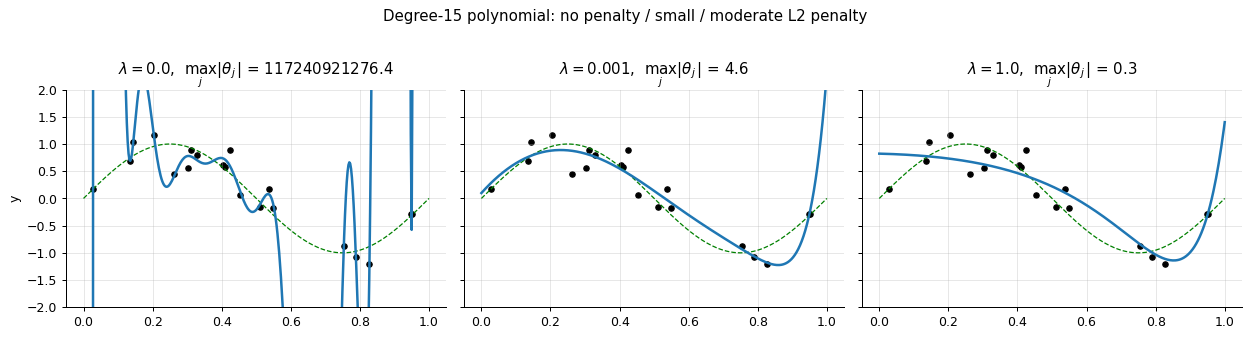

In [2]:
# degree-15 polynomial on 20 points: plain least squares vs. Ridge
f_true = lambda x: np.sin(2 * np.pi * x)
x = np.sort(rng.uniform(0, 1, 20)); y = f_true(x) + rng.normal(0, 0.2, 20)
grid = np.linspace(0, 1, 400)

def poly(x, d):                      # features x, x^2, ..., x^d, standardised with the training stats
    P = np.vander(x, d + 1, increasing=True)[:, 1:]
    return P
d = 15
P, Pg = poly(x, d), poly(grid, d)
mu, sd = P.mean(0), P.std(0)
Xd = np.c_[np.ones(len(x)), (P - mu) / sd]; Xg = np.c_[np.ones(len(grid)), (Pg - mu) / sd]

def ridge(X, y, lam):
    L = np.eye(X.shape[1]); L[0, 0] = 0            # do not penalise the intercept
    return np.linalg.solve(X.T @ X + lam * L, X.T @ y)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, lam in zip(axes, [0.0, 1e-3, 1.0]):
    th = np.linalg.lstsq(Xd, y, rcond=None)[0] if lam == 0 else ridge(Xd, y, lam)
    ax.scatter(x, y, color="k", s=18); ax.plot(grid, f_true(grid), "g--", lw=1)
    ax.plot(grid, Xg @ th, lw=2); ax.set_ylim(-2, 2)
    ax.set_title(rf"$\lambda={lam}$,  $\max_j|\theta_j|$ = {np.abs(th[1:]).max():.1f}")
axes[0].set_ylabel("y"); plt.suptitle("Degree-15 polynomial: no penalty / small / moderate L2 penalty", y=1.03)
plt.tight_layout(); plt.show()

## 2. The regularised loss

$$
J_{\text{reg}}(\boldsymbol{\theta}) = \underbrace{J(\boldsymbol{\theta})}_{\text{fit the data}} + \underbrace{\lambda\,R(\boldsymbol{\theta})}_{\text{keep }\boldsymbol{\theta}\text{ small}}, \qquad \lambda \ge 0 .
$$

| Name | Penalty $R(\boldsymbol{\theta})$ | Effect |
|---|---|---|
| L2 / Ridge / weight decay | $\sum_{j=1}^n \theta_j^2 = \lVert\boldsymbol{\theta}\rVert_2^2$ | shrinks all coefficients smoothly |
| L1 / Lasso | $\sum_{j=1}^n \lvert\theta_j\rvert = \lVert\boldsymbol{\theta}\rVert_1$ | sets some coefficients **exactly to 0** (feature selection) |
| Elastic Net | mix of both | sparse *and* stable with correlated features |

Two rules that always apply:

- **Do not penalise the intercept** $\theta_0$ (the sums start at $j=1$). Penalising it would pull predictions towards 0 for no reason; the intercept just sets the average level.
- **Standardise the features first.** The penalty treats every $\theta_j$ equally, but the size of $\theta_j$ depends on the units of $x_j$ (income in euros vs. thousands of euros gives a coefficient 1000× different). Without scaling, the penalty is arbitrary.

$\lambda$ is a hyperparameter: $\lambda = 0$ is the unregularised model; $\lambda\to\infty$ forces all $\theta_{j\ge1}\to 0$ (constant model). It is chosen by cross-validation (notebook 00).

*Conventions differ between books and libraries* (factors $\frac12$, $\frac1m$, or $C = 1/\lambda$ in scikit-learn's `LogisticRegression` and `SVC`). They only rescale $\lambda$.

## 3. L2 regularisation (Ridge regression)

For linear regression we use

$$
J(\boldsymbol{\theta}) = \frac{1}{2m}\Big[\lVert\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\rVert^2 + \lambda\sum_{j=1}^n\theta_j^2\Big].
$$

Let $\mathbf{L} = \mathrm{diag}(0, 1, \dots, 1)$ so that $\sum_{j\ge1}\theta_j^2 = \boldsymbol{\theta}^\top\mathbf{L}\boldsymbol{\theta}$.

**Gradient** (Fact 2 of notebook 01): $\;\nabla J = \frac{1}{m}\big[\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta}-\mathbf{y}) + \lambda\mathbf{L}\boldsymbol{\theta}\big]$.

**Gradient descent = "weight decay".** For $j\ge1$ the update is

$$
\theta_j \leftarrow \theta_j\Big(1 - \frac{\alpha\lambda}{m}\Big) - \frac{\alpha}{m}\sum_i\big(h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) - y^{(i)}\big)x^{(i)}_j :
$$

each step first shrinks $\theta_j$ by a constant factor, then applies the usual data gradient.

**Closed form.** Setting the gradient to zero:

$$
\boxed{\boldsymbol{\theta}^*_{\text{ridge}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{L})^{-1}\mathbf{X}^\top\mathbf{y}}
$$

**This inverse always exists for $\lambda>0$** (even with duplicated features or $n > m$). *Proof:* for $\mathbf{v}\ne 0$, $\;\mathbf{v}^\top(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{L})\mathbf{v} = \lVert\mathbf{X}\mathbf{v}\rVert^2 + \lambda\sum_{j\ge1}v_j^2$. The second term is $>0$ unless $v_1=\dots=v_n=0$; in that case $\mathbf{X}\mathbf{v} = v_0\mathbf{1}\neq\mathbf{0}$, so the first term is $>0$. The matrix is positive definite, hence invertible, and $J$ is strictly convex: **a unique minimum**. $\blacksquare$

**How it shrinks (one standardised feature).** Take one feature with $\frac1m\sum_i (x^{(i)})^2 = 1$, centred $y$, no intercept, and let $z = \frac{1}{m}\sum_i x^{(i)}y^{(i)}$ (this is the OLS solution). Expanding, $J(\theta) = \frac{1}{2}\big(1 + \frac{\lambda}{m}\big)\theta^2 - z\theta + \text{const}$, whose minimum is

$$
\theta_{\text{ridge}} = \frac{z}{1 + \lambda/m} = \frac{\theta_{\text{OLS}}}{1 + \lambda/m} .
$$

Ridge divides the coefficient by a constant factor. It gets smaller but **never exactly zero**.

## 4. L1 regularisation (Lasso)

$$
J(\boldsymbol{\theta}) = \frac{1}{2m}\lVert\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\rVert^2 + \lambda\sum_{j=1}^n\lvert\theta_j\rvert
$$

$|\theta_j|$ has a kink at 0, so there is no closed form. It is solved by coordinate descent (scikit-learn) or proximal / sub-gradient methods. It is still **convex** (a sum of convex functions).

**Why exact zeros? The one-feature case.** Same setting as above: we must minimise

$$
g(\theta) = \tfrac12(\theta - z)^2 + \lambda\lvert\theta\rvert .
$$

- If $\theta>0$: $g'(\theta) = \theta - z + \lambda = 0 \Rightarrow \theta = z - \lambda$, valid only if $z > \lambda$.
- If $\theta<0$: $g'(\theta) = \theta - z - \lambda = 0 \Rightarrow \theta = z + \lambda$, valid only if $z < -\lambda$.
- Otherwise ($|z| \le \lambda$) neither case applies and the minimum is at the kink, $\theta = 0$. (Check: the subgradient of $g$ at $0$ is the interval $[-z-\lambda,\,-z+\lambda]$, which contains $0$ exactly when $|z|\le\lambda$.)

Together, this is the **soft-thresholding** operator:

$$
\boxed{\theta_{\text{lasso}} = \mathrm{sign}(z)\,\max\big(|z| - \lambda,\, 0\big)}
$$

A feature whose OLS coefficient is smaller than $\lambda$ in absolute value is **switched off**. Bigger ones are shifted towards 0 by exactly $\lambda$. Intuition: the L2 penalty's slope $2\theta$ vanishes near 0, so it never quite pushes all the way to zero. The L1 penalty pushes with constant force $\lambda$ however small $\theta$ is.

**Geometric picture.** Minimising $J + \lambda R$ is equivalent to minimising $J$ subject to $R(\boldsymbol{\theta})\le t$ for some $t$. The solution is where the elliptical contours of $J$ first touch the constraint region. The L1 ball is a diamond with **corners on the axes**, and the contours usually hit a corner, where some $\theta_j=0$. The L2 ball is round, so the contact point generically has all coordinates non-zero.

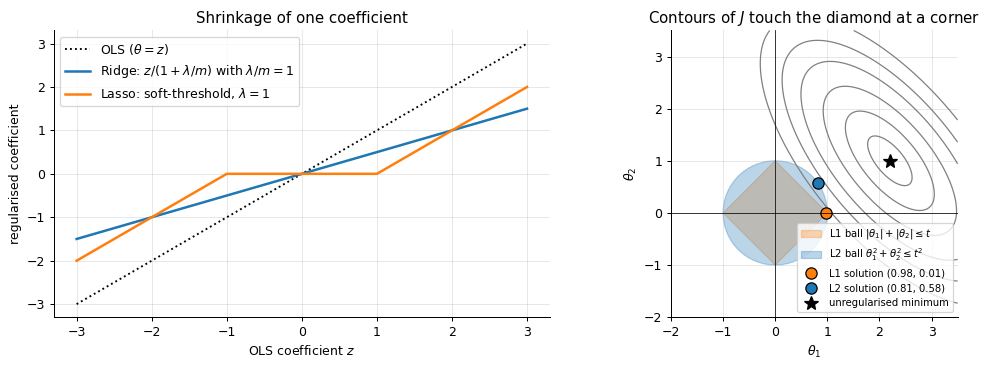

In [3]:
z = np.linspace(-3, 3, 400); lam = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(z, z, "k:", label="OLS ($\\theta=z$)")
axes[0].plot(z, z / (1 + lam), lw=2, label=r"Ridge: $z/(1+\lambda/m)$ with $\lambda/m=1$")
axes[0].plot(z, np.sign(z) * np.maximum(np.abs(z) - lam, 0), lw=2, label=r"Lasso: soft-threshold, $\lambda=1$")
axes[0].set_xlabel(r"OLS coefficient $z$"); axes[0].set_ylabel("regularised coefficient"); axes[0].legend()
axes[0].set_title("Shrinkage of one coefficient")

# constraint-region picture
A, B = np.meshgrid(np.linspace(-2, 3.5, 300), np.linspace(-2, 3.5, 300))
th_ols = np.array([2.2, 1.0]); M = np.array([[1.0, 0.6], [0.6, 0.8]])
Q = M[0, 0] * (A - th_ols[0])**2 + 2 * M[0, 1] * (A - th_ols[0]) * (B - th_ols[1]) + M[1, 1] * (B - th_ols[1])**2
ax = axes[1]
ax.contour(A, B, Q, levels=[0.1, 0.4, 0.9, 1.6, 2.35, 3.4], colors="gray", linewidths=1)
t = 1.0
ax.fill([t, 0, -t, 0], [0, t, 0, -t], alpha=0.3, color="C1", label=r"L1 ball $|\theta_1|+|\theta_2|\leq t$")
circ = plt.Circle((0, 0), t, alpha=0.3, color="C0", label=r"L2 ball $\theta_1^2+\theta_2^2\leq t^2$"); ax.add_patch(circ)
# solve the two constrained problems numerically on the grid
inside1 = np.abs(A) + np.abs(B) <= t; inside2 = A**2 + B**2 <= t**2
k1 = np.argmin(np.where(inside1, Q, np.inf)); k2 = np.argmin(np.where(inside2, Q, np.inf))
ax.plot(A.flat[k1], B.flat[k1], "o", color="C1", ms=9, mec="k", label=f"L1 solution ({A.flat[k1]:.2f}, {B.flat[k1]:.2f})")
ax.plot(A.flat[k2], B.flat[k2], "o", color="C0", ms=9, mec="k", label=f"L2 solution ({A.flat[k2]:.2f}, {B.flat[k2]:.2f})")
ax.plot(*th_ols, "k*", ms=12, label="unregularised minimum")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6); ax.set_aspect("equal")
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$"); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Contours of $J$ touch the diamond at a corner")
plt.tight_layout(); plt.show()

## 5. Elastic Net

$$
J(\boldsymbol{\theta}) = \frac{1}{2m}\lVert\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\rVert^2 + \lambda\Big[\rho\,\lVert\boldsymbol{\theta}\rVert_1 + \tfrac{1-\rho}{2}\lVert\boldsymbol{\theta}\rVert_2^2\Big], \qquad \rho\in[0,1].
$$

Lasso's weakness: among a group of highly correlated features it tends to keep one at random and drop the others, and it can select at most $m$ features. The L2 part makes correlated features share the weight (grouping effect) while the L1 part still produces sparsity. Use it when you want feature selection but have correlated features.

## 6. Regularisation as a prior (MAP estimation)

In notebooks 01–02 the unregularised loss was the negative log-likelihood. Now also put a **prior** on the parameters and maximise the posterior (Bayes' rule, $p(\boldsymbol{\theta}\mid\mathcal{D}) \propto p(\mathcal{D}\mid\boldsymbol{\theta})\,p(\boldsymbol{\theta})$):

$$
\hat{\boldsymbol{\theta}}_{\text{MAP}} = \arg\max_{\boldsymbol{\theta}}\big[\log p(\mathcal{D}\mid\boldsymbol{\theta}) + \log p(\boldsymbol{\theta})\big] = \arg\min_{\boldsymbol{\theta}}\big[\underbrace{-\log p(\mathcal{D}\mid\boldsymbol{\theta})}_{\text{loss}} \underbrace{-\log p(\boldsymbol{\theta})}_{\text{penalty}}\big].
$$

- **Gaussian prior** $\theta_j\sim\mathcal{N}(0,\tau^2)$: $\;-\log p(\boldsymbol{\theta}) = \frac{1}{2\tau^2}\sum_j\theta_j^2 + \text{const}$ → **L2**.
- **Laplace prior** $p(\theta_j)\propto e^{-|\theta_j|/b}$: $\;-\log p(\boldsymbol{\theta}) = \frac{1}{b}\sum_j|\theta_j| + \text{const}$ → **L1**. (The Laplace density has a sharp peak at 0, a "belief" that many coefficients are exactly zero.)

For linear regression with noise variance $\sigma^2$ the negative log-likelihood is $\frac{1}{2\sigma^2}\lVert\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\rVert^2 + \text{const}$, so with the Gaussian prior, MAP = Ridge with $\lambda = \sigma^2/\tau^2$: a **strong prior** (small $\tau$) or **noisy data** (large $\sigma$) means more regularisation.

## 7. Choosing $\lambda$; coefficient paths

A **coefficient path** shows each $\theta_j$ as $\lambda$ varies. Below: a dataset with 10 features, only 4 of which truly matter.

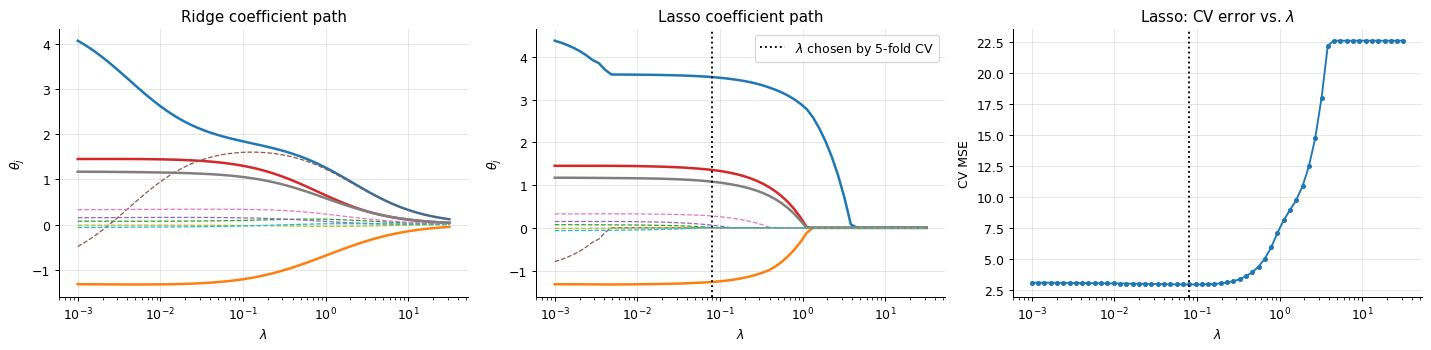

true theta         : [ 3.  -2.   0.   1.5  0.   0.   0.   1.   0.   0. ]
OLS (no penalty)   : [ 4.62 -1.32  0.07  1.45  0.15 -1.03  0.32  1.17 -0.01 -0.07]
lasso (CV lambda)  : [ 3.53 -1.27  0.01  1.35  0.06  0.    0.28  1.08 -0.   -0.  ]


In [4]:
from sklearn.linear_model import Ridge, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler

m, n = 120, 10
Xr = rng.normal(size=(m, n)); Xr[:, 5] = Xr[:, 0] + 0.1 * rng.normal(size=m)   # feature 5 ~ copy of feature 0
theta_true = np.array([3, -2, 0, 1.5, 0, 0, 0, 1, 0, 0])
y = Xr @ theta_true + rng.normal(0, 1.5, m)
Xs = StandardScaler().fit_transform(Xr)

lams = np.logspace(-3, 1.5, 60)
paths_l1 = np.array([Lasso(alpha=a, max_iter=50000).fit(Xs, y).coef_ for a in lams])
paths_l2 = np.array([Ridge(alpha=a * m).fit(Xs, y).coef_ for a in lams])
cv = LassoCV(alphas=lams, cv=5, max_iter=50000).fit(Xs, y)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, P, name in [(axes[0], paths_l2, "Ridge"), (axes[1], paths_l1, "Lasso")]:
    for j in range(n):
        ax.plot(lams, P[:, j], lw=2 if theta_true[j] != 0 else 1, ls="-" if theta_true[j] != 0 else "--")
    ax.set_xscale("log"); ax.set_xlabel(r"$\lambda$"); ax.set_ylabel(r"$\theta_j$"); ax.set_title(f"{name} coefficient path")
axes[1].axvline(cv.alpha_, color="k", ls=":", label=r"$\lambda$ chosen by 5-fold CV"); axes[1].legend()
mse_path = cv.mse_path_.mean(1)
axes[2].plot(cv.alphas_, mse_path, "o-", ms=3); axes[2].axvline(cv.alpha_, color="k", ls=":")
axes[2].set_xscale("log"); axes[2].set_xlabel(r"$\lambda$"); axes[2].set_ylabel("CV MSE"); axes[2].set_title("Lasso: CV error vs. $\\lambda$")
plt.tight_layout(); plt.show()
print("true theta         :", theta_true)
print("OLS (no penalty)   :", np.linalg.lstsq(np.c_[np.ones(m), Xs], y, rcond=None)[0][1:].round(2))
print("lasso (CV lambda)  :", cv.coef_.round(2))

Solid lines are the true non-zero coefficients, dashed the irrelevant ones. Ridge shrinks everything gradually. Lasso switches coefficients off one by one as $\lambda$ grows, and at the CV-chosen $\lambda$ it has dropped most irrelevant features. Look at feature 0 and its near-copy, feature 5: OLS gives them large coefficients of opposite sign (4.6 and −1.0, pure collinearity noise), while Lasso keeps feature 0 and switches feature 5 off. Which one of a correlated pair Lasso keeps is somewhat arbitrary. (Coefficients are on the standardised scale, so they differ slightly from `theta_true`.)

**Rule of thumb**: search $\lambda$ on a log grid by $k$-fold CV, with the scaling done inside the CV loop (scikit-learn `Pipeline`).

## 8. Regularised logistic regression

Same idea, added to the cross-entropy:

$$
J(\boldsymbol{\theta}) = -\frac{1}{m}\sum_{i=1}^m\Big[y^{(i)}\log h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) + (1-y^{(i)})\log(1-h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}))\Big] + \frac{\lambda}{2m}\sum_{j=1}^n\theta_j^2,
$$

$$
\nabla J = \frac{1}{m}\Big[\mathbf{X}^\top\big(\sigma(\mathbf{X}\boldsymbol{\theta}) - \mathbf{y}\big) + \lambda\mathbf{L}\boldsymbol{\theta}\Big].
$$

- The Hessian gains $+\frac{\lambda}{m}\mathbf{L}$, so the problem becomes strictly convex and **always has a finite solution**, even for separable data.
- L1 works the same way and gives sparse logistic models.
- In scikit-learn, `LogisticRegression` is **L2-regularised by default** with `C = 1/λ` (default `C=1`). Large `C` = weak regularisation.

The next cell fits degree-6 polynomial features (27 features from 2 inputs) with three values of `C`.

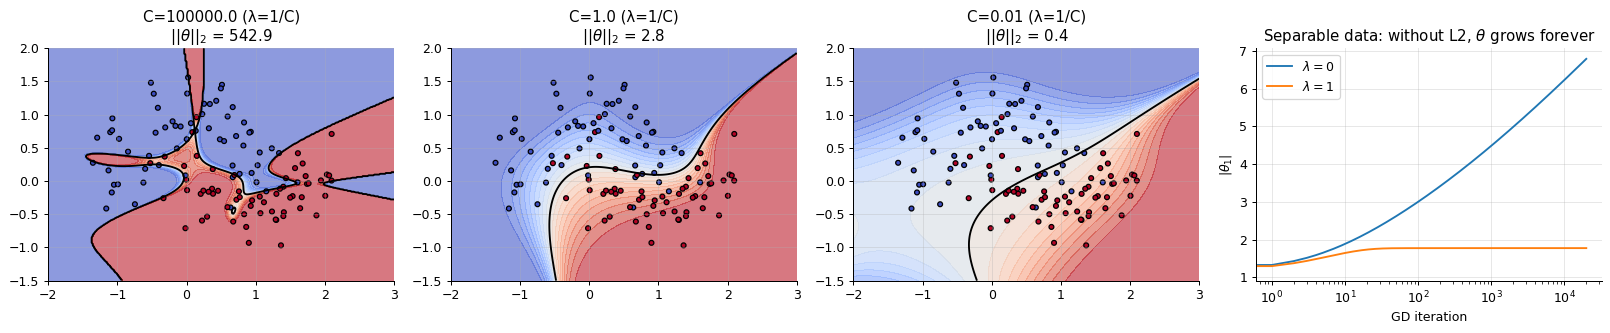

In [5]:
from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

Xm, ym = make_moons(n_samples=120, noise=0.3, random_state=0)
g1, g2 = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300)); G = np.c_[g1.ravel(), g2.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, C in zip(axes[:3], [1e5, 1.0, 0.01]):
    model = make_pipeline(PolynomialFeatures(6), StandardScaler(), LogisticRegression(C=C, max_iter=20000)).fit(Xm, ym)
    Z = model.predict_proba(G)[:, 1].reshape(g1.shape)
    ax.contourf(g1, g2, Z, levels=20, cmap="coolwarm", alpha=0.6); ax.contour(g1, g2, Z, levels=[0.5], colors="k")
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", edgecolor="k", s=15)
    w = model[-1].coef_[0]
    ax.set_title(f"C={C} (λ=1/C)\n" + r"$||\theta||_2$" + f" = {np.linalg.norm(w):.1f}")

# separable data: ||theta|| during gradient descent, with and without L2
Xs2 = np.c_[np.ones(40), np.r_[rng.normal(-2, 0.7, 20), rng.normal(2, 0.7, 20)]]; ys2 = np.r_[np.zeros(20), np.ones(20)]
sig = lambda t: 1 / (1 + np.exp(-t))
for lam, lab in [(0, r"$\lambda=0$"), (1.0, r"$\lambda=1$")]:
    th = np.zeros(2); norms = []
    for it in range(20000):
        g = (Xs2.T @ (sig(Xs2 @ th) - ys2) + lam * np.r_[0, th[1]]) / 40
        th -= 1.0 * g; norms.append(abs(th[1]))
    axes[3].plot(norms, label=lab)
axes[3].set_xscale("log"); axes[3].set_xlabel("GD iteration"); axes[3].set_ylabel(r"$|\theta_1|$"); axes[3].legend()
axes[3].set_title("Separable data: without L2, $\\theta$ grows forever")
plt.tight_layout(); plt.show()

## 9. Input variables

The model is linear in $\boldsymbol{\theta}$, but we decide what goes into $\mathbf{x}$. Most of the practical skill with linear models is here.

### 9.1 Numerical features: scaling

- **Standardise** ($\tilde{x}_j = (x_j-\mu_j)/\sigma_j$) before gradient descent (conditioning, notebook 01) and before any regularisation (fair penalty).
- The fitted **predictions** of an *unregularised* model don't depend on the scaling (the coefficients just rescale), but the regularised ones do.
- Compute $\mu_j, \sigma_j$ **on the training data only** and reuse them on validation/test/production data.
- Interpretation after standardising: $\theta_j$ = effect of a one-standard-deviation increase of $x_j$. This makes coefficients comparable across features.

### 9.2 Categorical features: one-hot encoding and the dummy trap

A categorical variable with $K$ levels (e.g. vehicle type ∈ {car, van, motorbike}) cannot enter as 1, 2, 3: that would impose an order and equal spacing. Instead create **indicator (dummy) variables** $d_k = \mathbb{1}[\text{level} = k]$.

**Dummy variable trap.** With an intercept, use only $K-1$ dummies. *Proof:* every row has exactly one $d_k=1$, so $d_1 + \dots + d_K = 1 = x_0$. A column of $\mathbf{X}$ is then a linear combination of others, so $\mathbf{X}^\top\mathbf{X}$ is singular (notebook 01, section 8) and the coefficients are not identifiable. Dropping one level (the **reference level**) fixes it; each remaining $\theta_k$ is then "the difference between level $k$ and the reference level". (With L2 regularisation, keeping all $K$ is also fine, since the penalty makes the solution unique.)

- **Ordinal** variables (low < medium < high) can be coded as integers *if* equal spacing is plausible, otherwise one-hot.
- **High-cardinality** categories (postcode, car model): group rare levels, or use target/frequency encoding computed inside the CV folds to avoid leakage.

### 9.3 Non-linear effects and interactions

Because the model only needs to be linear in $\boldsymbol{\theta}$, we can add any fixed transformation of the inputs:

| Pattern in the data | Feature to add |
|---|---|
| curved relationship | $x^2, x^3$, splines, bins |
| multiplicative / skewed variables (income, prices, counts) | $\log x$ (or $\log(1+x)$) |
| effect of $x_1$ depends on $x_2$ | interaction $x_1x_2$ |
| periodic (hour, month) | $\sin(2\pi t/T), \cos(2\pi t/T)$ |

For logistic regression the same features make the decision boundary curved (section 8). Adding features increases variance, so pair it with regularisation and CV.

### 9.4 Collinearity

Collinearity does not hurt predictions much, but it makes **individual coefficients unreliable**. Under the linear-model assumptions (section 10) the OLS estimator has

$$
\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}, \qquad \mathrm{Cov}(\hat{\boldsymbol{\theta}}) = \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}.
$$

*Proof.* $\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ with $\mathbf{y} = \mathbf{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$ gives $\hat{\boldsymbol{\theta}} = \boldsymbol{\theta} + (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\varepsilon}$. Take the expectation ($\mathbb{E}[\boldsymbol{\varepsilon}]=0$) for the first claim. For the second, with $\mathbf{A} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$: $\mathrm{Cov} = \mathbf{A}\,\sigma^2\mathbf{I}\,\mathbf{A}^\top = \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}$. $\blacksquare$

When columns are nearly dependent, $\mathbf{X}^\top\mathbf{X}$ has a tiny eigenvalue, its inverse a huge one, and the variance of the coefficients explodes. The standard diagnostic is the **variance inflation factor**, $\mathrm{VIF}_j = \frac{1}{1-R_j^2}$, where $R_j^2$ is the $R^2$ of regressing $x_j$ on all other features; VIF $> 5$–$10$ signals a problem. Remedies: drop or combine features, or use Ridge.

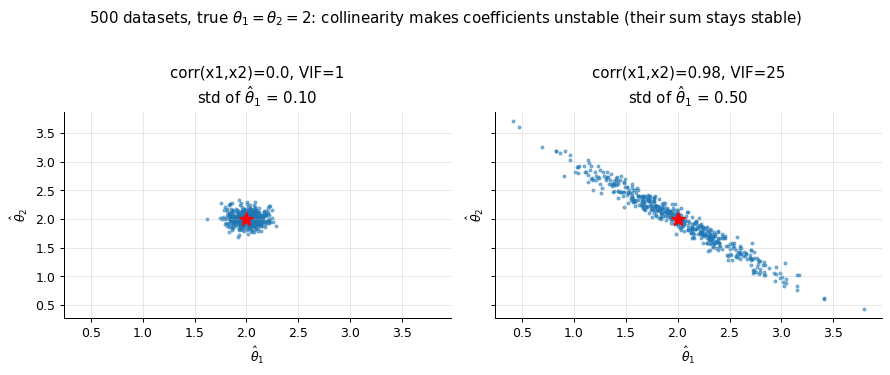

In [6]:
def fit_many(rho, reps=500, m=100):
    est = []
    for _ in range(reps):
        x1 = rng.normal(size=m); x2 = rho * x1 + np.sqrt(1 - rho**2) * rng.normal(size=m)
        Xc = np.c_[np.ones(m), x1, x2]; yc = 1 + 2 * x1 + 2 * x2 + rng.normal(size=m)
        est.append(np.linalg.lstsq(Xc, yc, rcond=None)[0][1:])
    return np.array(est)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, rho in zip(axes, [0.0, 0.98]):
    E = fit_many(rho)
    ax.scatter(E[:, 0], E[:, 1], s=5, alpha=0.5); ax.plot(2, 2, "r*", ms=12)
    ax.set_title(f"corr(x1,x2)={rho}, VIF={1/(1-rho**2):.0f}\nstd of $\\hat\\theta_1$ = {E[:,0].std():.2f}")
    ax.set_xlabel(r"$\hat\theta_1$"); ax.set_ylabel(r"$\hat\theta_2$")
plt.suptitle("500 datasets, true $\\theta_1=\\theta_2=2$: collinearity makes coefficients unstable (their sum stays stable)", y=1.03)
plt.tight_layout(); plt.show()

### 9.5 Other practical points

- **Missing values**: impute (median/mode, fitted on training data) and add a "was missing" indicator if missingness may be informative.
- **Outliers** have a large influence on squared loss (residuals are squared). Inspect them; consider $\log$ transforms, clipping, or a robust loss (Huber).
- **Leakage features**: variables that are only known *after* the outcome (e.g. "claim paid amount" when predicting fraud at claim opening). They make validation scores great and production useless.

## 10. Assumptions of linear regression

The model $y = \boldsymbol{\theta}^\top\mathbf{x} + \varepsilon$ is fit by least squares no matter what. The assumptions decide whether the estimates, their uncertainty and the predictions can be trusted.

| # | Assumption | Formal | What breaks if violated | How to check |
|---|---|---|---|---|
| 1 | **Linearity** | $\mathbb{E}[y\mid\mathbf{x}] = \boldsymbol{\theta}^\top\mathbf{x}$ | biased predictions, systematic errors | residuals vs. fitted show a curve |
| 2 | **Exogeneity** | $\mathbb{E}[\varepsilon\mid\mathbf{x}] = 0$ (no omitted confounders) | coefficients biased, can't be read causally | domain knowledge |
| 3 | **Independent errors** | $\varepsilon^{(i)}$ independent | standard errors too small, over-confidence | residuals vs. time/order, autocorrelation |
| 4 | **Homoscedasticity** | $\mathrm{Var}(\varepsilon\mid\mathbf{x}) = \sigma^2$ constant | OLS no longer the best linear estimator; wrong standard errors | residuals fan out vs. fitted |
| 5 | **Normal errors** | $\varepsilon\sim\mathcal{N}(0,\sigma^2)$ | only exact tests/intervals in small samples (not needed for the estimates) | Q-Q plot of residuals |
| 6 | **No perfect multicollinearity** | columns of $\mathbf{X}$ independent | $\mathbf{X}^\top\mathbf{X}$ singular, coefficients not unique | rank, VIF |

**Gauss–Markov theorem.** Under 1–4 and 6, OLS is **BLUE**: the Best (minimum variance) Linear Unbiased Estimator. Unbiasedness was proved in 9.4 (it needs 1, 2, 6). Normality (5) is only needed for the MLE interpretation (notebook 01) and exact $t$/$F$ tests.

Fixes: non-linearity → transform/add features; heteroscedasticity → transform $y$ (e.g. $\log y$), weighted least squares, or robust standard errors; dependence → time-series models, grouped CV; multicollinearity → drop/combine features or Ridge.

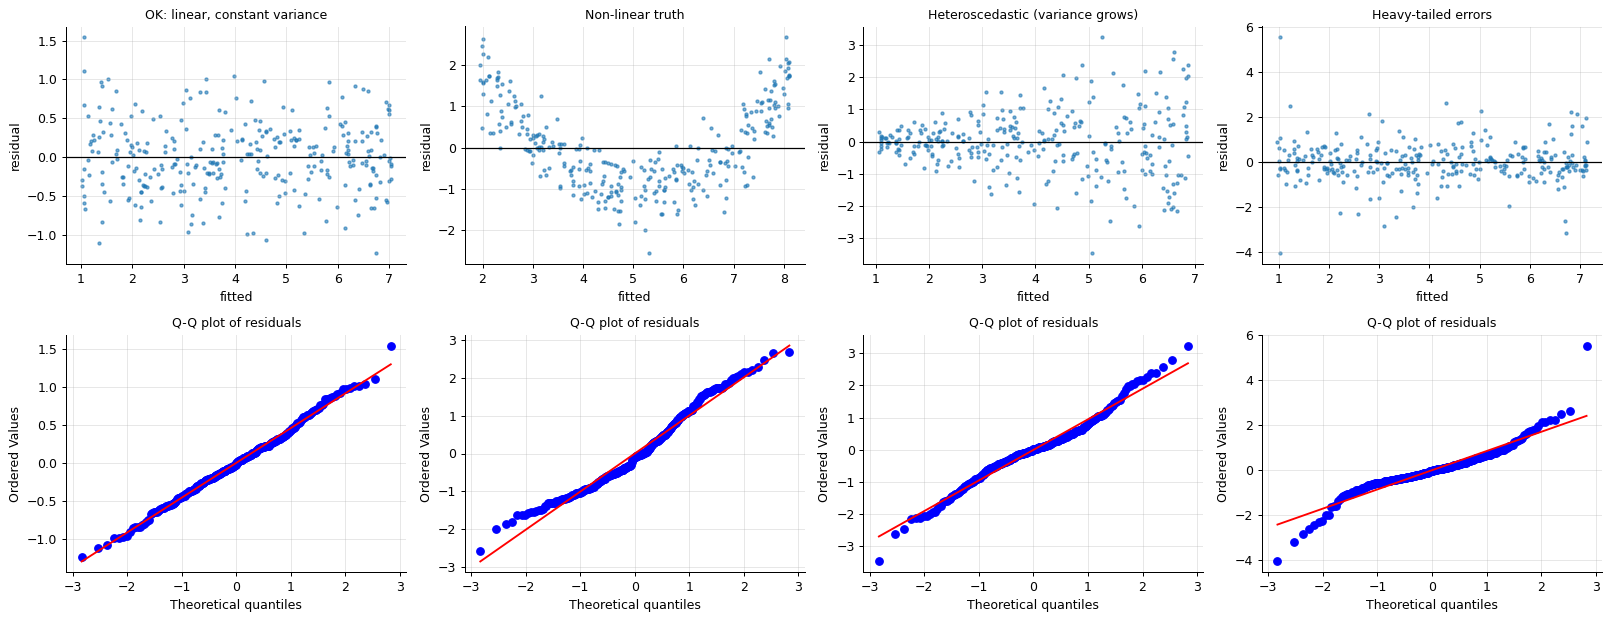

In [7]:
from scipy import stats
mm = 300; xx = rng.uniform(0, 3, mm)
cases = {
    "OK: linear, constant variance": 1 + 2 * xx + rng.normal(0, 0.5, mm),
    "Non-linear truth": 1 + 2 * xx + 1.2 * (xx - 1.5) ** 2 + rng.normal(0, 0.5, mm),
    "Heteroscedastic (variance grows)": 1 + 2 * xx + rng.normal(0, 0.15 + 0.5 * xx, mm),
    "Heavy-tailed errors": 1 + 2 * xx + 0.5 * rng.standard_t(2, mm),
}
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for k, (name, yy) in enumerate(cases.items()):
    Xc = np.c_[np.ones(mm), xx]; th = np.linalg.lstsq(Xc, yy, rcond=None)[0]; fit = Xc @ th; r = yy - fit
    axes[0, k].scatter(fit, r, s=6, alpha=0.6); axes[0, k].axhline(0, color="k", lw=1)
    axes[0, k].set_title(name, fontsize=10); axes[0, k].set_xlabel("fitted"); axes[0, k].set_ylabel("residual")
    stats.probplot(r, dist="norm", plot=axes[1, k]); axes[1, k].set_title("Q-Q plot of residuals", fontsize=10)
plt.tight_layout(); plt.show()

**How to read them.** Top row: a healthy residual plot is a horizontal band with no shape. A curve means non-linearity; a funnel means heteroscedasticity. Bottom row: in a Q-Q plot, normal residuals lie on the line; S-shaped departures at the ends mean heavy tails (outliers are more frequent than Gaussian).

## 11. Assumptions of logistic regression

Logistic regression needs **fewer** assumptions than linear regression. There is no error term, so no normality or homoscedasticity is required: the Bernoulli variance $p(1-p)$ is part of the model.

| # | Assumption | Notes / check |
|---|---|---|
| 1 | **Binary (or Bernoulli) outcome** | multiclass → softmax (notebook 04) |
| 2 | **Independent observations** | repeated measures on the same entity break it (use grouped CV, mixed models) |
| 3 | **Linearity of the log-odds** in each (numeric) feature: $\log\frac{p}{1-p} = \boldsymbol{\theta}^\top\mathbf{x}$ | bin a feature, plot the empirical logit $\log\frac{\bar y}{1-\bar y}$ per bin: it should be roughly a straight line; otherwise add transforms/splines |
| 4 | **No perfect multicollinearity** | as for linear regression (VIF) |
| 5 | **No perfect separation** | otherwise $\lVert\boldsymbol{\theta}\rVert\to\infty$; use L2 regularisation |
| 6 | **Enough data per parameter** | rule of thumb: at least ~10–20 events of the *rarer* class per feature for stable, unregularised estimates |

Things that are **not** assumed: normally distributed features, linear relation between $\mathbf{x}$ and $p$ itself (the relation to $p$ is S-shaped by design), equal variance.

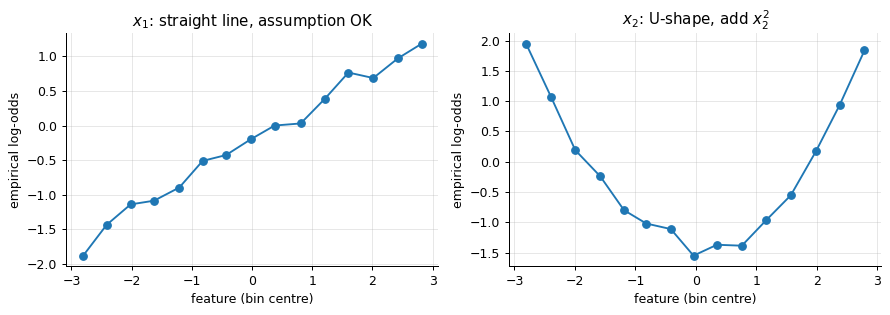

In [8]:
# Check linearity of the log-odds by binning: true logit is linear in x1 but quadratic in x2
mm = 6000
x1 = rng.uniform(-3, 3, mm); x2 = rng.uniform(-3, 3, mm)
yb = rng.random(mm) < 1 / (1 + np.exp(-(0.8 * x1 + 0.6 * x2 ** 2 - 2)))

def empirical_logit(xv, yv, bins=15):
    edges = np.quantile(xv, np.linspace(0, 1, bins + 1)); idx = np.clip(np.digitize(xv, edges[1:-1]), 0, bins - 1)
    c = np.array([xv[idx == b].mean() for b in range(bins)]); p = np.array([yv[idx == b].mean() for b in range(bins)])
    return c, np.log(p / (1 - p))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, xv, name in [(axes[0], x1, "$x_1$: straight line, assumption OK"), (axes[1], x2, "$x_2$: U-shape, add $x_2^2$")]:
    c, lg = empirical_logit(xv, yb); ax.plot(c, lg, "o-"); ax.set_title(name); ax.set_xlabel("feature (bin centre)"); ax.set_ylabel("empirical log-odds")
plt.tight_layout(); plt.show()

## Summary

- Regularisation = loss + $\lambda\times$ penalty; don't penalise $\theta_0$; standardise features first; choose $\lambda$ by CV.
- **L2 (Ridge)**: closed form $(\mathbf{X}^\top\mathbf{X}+\lambda\mathbf{L})^{-1}\mathbf{X}^\top\mathbf{y}$, always unique; shrinks, never zeroes; Gaussian prior; weight decay in GD.
- **L1 (Lasso)**: soft-thresholding, exact zeros, feature selection; Laplace prior. **Elastic Net** for correlated features.
- In logistic regression, L2 guarantees a finite solution; scikit-learn uses `C = 1/λ` and regularises by default.
- Inputs: scale numerics, one-hot categoricals with $K-1$ dummies, add transforms/interactions for non-linear effects, watch collinearity (VIF) and leakage.
- Linear regression assumes linearity, exogeneity, independence, constant variance (and normality for exact inference); check with residual and Q-Q plots. Logistic regression assumes independence, linear log-odds, no separation and enough events per feature.